# 05 — Regresión logística para AndinaLog 03B

## Objetivo

Entrenar un modelo sencillo que estime si ocurrirá una desviación térmica durante los siguientes 60 minutos.

El modelo utilizará únicamente las cinco variables solicitadas:

1. Temperatura actual.
2. Humedad actual.
3. Desviación térmica actual.
4. Temperatura anterior.
5. Variación de temperatura durante los últimos 30 minutos.

Los viajes se separarán entre entrenamiento y prueba para evitar que lecturas consecutivas del mismo recorrido aparezcan en ambos grupos.

## Antes de comenzar

Este notebook intenta responder una pregunta concreta: **con la información disponible en una lectura, ¿habrá una desviación térmica durante los próximos 60 minutos?**

Para comprender los resultados utilizaremos estas palabras:

- **Modelo:** procedimiento matemático que aprende relaciones a partir de viajes anteriores.
- **Entrenamiento:** datos utilizados para que el modelo aprenda.
- **Prueba:** viajes separados que el modelo no vio durante el aprendizaje y que se utilizan para comprobarlo.
- **Clase 0:** durante los siguientes 60 minutos no se observó una desviación.
- **Clase 1:** durante los siguientes 60 minutos sí se observó al menos una desviación.
- **Probabilidad estimada:** puntuación entre 0 y 1. Cuanto más alta sea, mayor es el riesgo calculado por el modelo.
- **Umbral 0,50:** si la probabilidad es igual o mayor que 0,50, el modelo genera una alerta.

La predicción es una ayuda para ordenar revisiones. No sustituye la decisión de una persona ni demuestra la causa de una desviación.

## 1. Librerías y configuración

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, confusion_matrix, f1_score,
    precision_recall_curve, precision_score, recall_score,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

CONFIG = {
    "ruta_gold": Path("outputs/03_silver_gold_iot/andinalog_iot_modelado_gold.csv"),
    "carpeta_salida": Path("outputs/05_regresion_logistica_iot"),
    "semilla": 42,
    "proporcion_prueba": 0.20,
    "umbral": 0.50,
    "objetivo": "desviacion_proximos_60min_flag",
    "grupo": "viaje_id",
    "predictores": [
        "temperatura_cabina_c",
        "humedad_cabina_pct",
        "desviacion_termica_flag",
        "temperatura_anterior",
        "variacion_temperatura_30min",
    ],
}

CONFIG["carpeta_salida"].mkdir(parents=True, exist_ok=True)
RUTA_INFORME = CONFIG["carpeta_salida"] / "Informe_05_Regresion_Logistica_IoT.md"

print("Semilla:", CONFIG["semilla"])
print("Proporción de prueba:", CONFIG["proporcion_prueba"])
print("Umbral de clasificación:", CONFIG["umbral"])

Semilla: 42
Proporción de prueba: 0.2
Umbral de clasificación: 0.5


### Explicación

La **semilla 42** permite repetir exactamente la misma separación de viajes y obtener resultados comparables en otra ejecución.

El **umbral 0,50** convierte una probabilidad en una respuesta:

- Probabilidad menor que 0,50: el modelo responde “no habrá desviación”.
- Probabilidad igual o mayor que 0,50: el modelo responde “sí habrá desviación”.

Este valor se mantiene fijo para evaluar el modelo. No significa que 0,50 sea necesariamente el mejor límite para la operación de AndinaLog. Cambiarlo después de observar la prueba haría que la evaluación pareciera mejor de manera artificial.

## 2. Carga y selección de datos

In [2]:
ruta_gold = CONFIG["ruta_gold"]
if not ruta_gold.exists():
    alternativa = Path("/content/andinalog_iot_modelado_gold.csv")
    if alternativa.exists():
        ruta_gold = alternativa
    else:
        raise FileNotFoundError("No se encontró el CSV Gold. Ajusta CONFIG['ruta_gold'].")

gold = pd.read_csv(ruta_gold)
requeridas = CONFIG["predictores"] + [CONFIG["objetivo"], CONFIG["grupo"], "ventana_objetivo_evaluable"]
faltantes = [c for c in requeridas if c not in gold.columns]
if faltantes:
    raise ValueError(f"Faltan columnas necesarias: {faltantes}")

# Solo se modelan las filas cuyo futuro de 60 minutos pudo observarse.
modelado = gold.loc[
    gold["ventana_objetivo_evaluable"].eq(True)
    & gold[CONFIG["objetivo"]].notna()
].copy()

X = modelado[CONFIG["predictores"]]
y = modelado[CONFIG["objetivo"]].astype(int)
grupos = modelado[CONFIG["grupo"]]

print(f"Filas Gold: {len(gold):,}")
print(f"Filas utilizables para el modelo: {len(modelado):,}")
print(f"Viajes utilizables: {grupos.nunique():,}")
print("Predictores:", CONFIG["predictores"])
display(X.isna().sum().rename("faltantes").to_frame())

Filas Gold: 28,465
Filas utilizables para el modelo: 25,797
Viajes utilizables: 1,200
Predictores: ['temperatura_cabina_c', 'humedad_cabina_pct', 'desviacion_termica_flag', 'temperatura_anterior', 'variacion_temperatura_30min']


,faltantes
temperatura_cabina_c,0
humedad_cabina_pct,0
desviacion_termica_flag,0
temperatura_anterior,1188
variacion_temperatura_30min,1452


### Explicación

Gold contiene 28.465 lecturas, pero solamente **25.797** tienen información suficiente para comprobar qué ocurrió durante los 60 minutos siguientes.

Las **2.668 lecturas restantes** corresponden principalmente al final de los viajes. Como no existe una hora futura completa, no podemos afirmar si después ocurrió o no una desviación. Por eso no se utilizan para enseñar ni evaluar el modelo.

Algunos antecedentes, como la temperatura anterior o la variación de 30 minutos, pueden estar vacíos al comienzo de un viaje. Esos valores se completan dentro del proceso de entrenamiento con una mediana aprendida exclusivamente de los viajes de entrenamiento. El conjunto de prueba no participa en esa decisión.

## 3. Balance del objetivo

In [3]:
balance = y.value_counts().reindex([0, 1], fill_value=0)
prevalencia_total = y.mean()
display(pd.DataFrame({
    "lecturas": balance,
    "porcentaje": (balance / len(y) * 100).round(2),
}))
print(f"Desviaciones futuras: {balance[1]:,} de {len(y):,} ({prevalencia_total * 100:.2f}%).")

,lecturas,porcentaje
desviacion_proximos_60min_flag,,
0,24501,94.98
1,1296,5.02


Desviaciones futuras: 1,296 de 25,797 (5.02%).


### Interpretación

De las 25.797 lecturas evaluables:

- **24.501** no presentan una desviación futura.
- **1.296** sí presentan una desviación durante los siguientes 60 minutos.

Esto significa que solamente **5,02 de cada 100 lecturas** pertenecen a la clase positiva.

Por este desbalance, un procedimiento que respondiera siempre “no habrá desviación” acertaría aproximadamente 95 de cada 100 filas. Sin embargo, no detectaría ninguna de las 1.296 desviaciones. Por esa razón, el porcentaje total de aciertos puede ser engañoso y se utilizan métricas específicas para los eventos importantes.

## 4. Separación por viaje

In [4]:
divisor = GroupShuffleSplit(
    n_splits=1,
    test_size=CONFIG["proporcion_prueba"],
    random_state=CONFIG["semilla"],
)
indices_train, indices_test = next(divisor.split(X, y, groups=grupos))

X_train, X_test = X.iloc[indices_train].copy(), X.iloc[indices_test].copy()
y_train, y_test = y.iloc[indices_train].copy(), y.iloc[indices_test].copy()
grupos_train = grupos.iloc[indices_train]
grupos_test = grupos.iloc[indices_test]

viajes_compartidos = set(grupos_train) & set(grupos_test)
resumen_split = pd.DataFrame({
    "partición": ["Entrenamiento", "Prueba"],
    "filas": [len(X_train), len(X_test)],
    "viajes": [grupos_train.nunique(), grupos_test.nunique()],
    "positivos": [int(y_train.sum()), int(y_test.sum())],
    "prevalencia_pct": [round(y_train.mean() * 100, 2), round(y_test.mean() * 100, 2)],
})
display(resumen_split)
print("Viajes compartidos entre entrenamiento y prueba:", len(viajes_compartidos))

if viajes_compartidos:
    raise AssertionError("La división mezcló viajes entre entrenamiento y prueba.")
if y_test.nunique() < 2:
    raise AssertionError("La prueba no contiene las dos clases y no permite evaluar el modelo.")

,partición,filas,viajes,positivos,prevalencia_pct
0,Entrenamiento,20623,960,1018,4.94
1,Prueba,5174,240,278,5.37


Viajes compartidos entre entrenamiento y prueba: 0


### Interpretación

La separación se realiza por viaje completo:

- Entrenamiento: **20.623 lecturas de 960 viajes**.
- Prueba: **5.174 lecturas de 240 viajes**.
- Viajes compartidos entre ambos grupos: **0**.

Esto es importante porque las lecturas consecutivas del mismo viaje suelen parecerse. Si algunas lecturas de un viaje estuvieran en entrenamiento y otras en prueba, el modelo podría parecer bueno solamente porque ya conoce ese recorrido. Aquí se evalúa con viajes que no vio durante el aprendizaje.

## 5. Preparación y entrenamiento

In [5]:
modelo = Pipeline(steps=[
    ("imputacion", SimpleImputer(strategy="median")),
    ("escalado", StandardScaler()),
    ("regresion", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=CONFIG["semilla"],
    )),
])

modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente.")
print("Imputación: mediana aprendida solo con entrenamiento.")
print("Escalado: promedio y desviación aprendidos solo con entrenamiento.")
print("Balance: cada clase recibe un peso inverso a su frecuencia.")

Modelo entrenado correctamente.
Imputación: mediana aprendida solo con entrenamiento.
Escalado: promedio y desviación aprendidos solo con entrenamiento.
Balance: cada clase recibe un peso inverso a su frecuencia.


### Explicación

Antes de entrenar se aplican tres pasos:

1. **Imputación por mediana:** completa antecedentes temporales faltantes con un valor central calculado únicamente en entrenamiento. No modifica el CSV Gold y no inventa el objetivo futuro.
2. **Escalado:** coloca temperatura, humedad y variación en escalas comparables para que una unidad numéricamente grande no domine solo por su tamaño.
3. **Balance de clases:** asigna más importancia a las desviaciones, porque son mucho menos frecuentes que los casos normales.

Los tres pasos viven dentro de un `Pipeline`. Esto garantiza que la información de prueba no se utilice para preparar ni entrenar el modelo.

### Resumen metodológico y por qué se hizo así

- Se utilizan **25.797 lecturas evaluables**. Las lecturas sin 60 minutos futuros completos no pueden tener una respuesta conocida y, por eso, no se usan para entrenar ni evaluar el modelo.
- El entrenamiento contiene **20.623 lecturas de 960 viajes** y la prueba contiene **5.174 lecturas de 240 viajes**.
- No hay viajes compartidos entre entrenamiento y prueba. Esto evita que el modelo sea evaluado con otras lecturas de un viaje que ya conoció.
- Los valores faltantes de los predictores se completan con la mediana calculada únicamente en entrenamiento.
- Las variables se colocan en una escala comparable y el modelo utiliza `class_weight="balanced"` porque las desviaciones futuras son poco frecuentes.
- La semilla 42 permite repetir la misma división y el mismo resultado.
- Se utiliza un umbral de 0,50: una probabilidad igual o superior produce una alerta. Este umbral no se ajustó usando el conjunto de prueba.

En palabras sencillas, el modelo estudia viajes históricos y después se comprueba con viajes distintos. Así la evaluación se parece más a la situación real de recibir un viaje que el modelo todavía no ha visto.

## 6. Predicciones y línea base

In [6]:
probabilidades = modelo.predict_proba(X_test)[:, 1]
predicciones = (probabilidades >= CONFIG["umbral"]).astype(int)

# Línea base adecuada al desbalance: siempre predice la clase mayoritaria (0).
predicciones_base = np.zeros(len(y_test), dtype=int)
probabilidades_base = np.zeros(len(y_test), dtype=float)

print("Predicciones positivas del modelo:", int(predicciones.sum()))
print("Predicciones positivas de la línea base:", int(predicciones_base.sum()))

Predicciones positivas del modelo: 461


Predicciones positivas de la línea base: 0


### Interpretación de las predicciones y la línea base

El modelo calcula una probabilidad para cada una de las 5.174 lecturas de prueba y genera una alerta cuando esa probabilidad alcanza 0,50.

La **línea base** es una referencia muy sencilla: siempre responde que no habrá desviación. Como la mayoría de las lecturas son normales, esa referencia acierta muchos casos negativos, pero genera **cero alertas** y detecta **cero desviaciones**.

El objetivo del modelo no es solamente superar el número total de aciertos de la línea base. Debe demostrar que puede encontrar una parte útil de las desviaciones reales sin producir una cantidad incontrolable de falsas alertas.

## 7. Métricas finales sobre prueba

In [7]:
def calcular_metricas(nombre, y_real, y_pred, probabilidades_pred):
    return {
        "modelo": nombre,
        "precision": precision_score(y_real, y_pred, zero_division=0),
        "recall": recall_score(y_real, y_pred, zero_division=0),
        "f1": f1_score(y_real, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_real, probabilidades_pred),
        "pr_auc": average_precision_score(y_real, probabilidades_pred),
    }

metricas = pd.DataFrame([
    calcular_metricas("Regresión logística", y_test, predicciones, probabilidades),
    calcular_metricas("Línea base: siempre 0", y_test, predicciones_base, probabilidades_base),
]).set_index("modelo")

display((metricas * 100).round(2).rename(columns=lambda c: c + " (%)"))
print(f"Prevalencia positiva en prueba: {y_test.mean() * 100:.2f}%")

,precision (%),recall (%),f1 (%),roc_auc (%),pr_auc (%)
modelo,,,,,
Regresión logística,28.2,46.76,35.18,74.89,37.32
Línea base: siempre 0,0.0,0.00,0.00,50.00,5.37


Prevalencia positiva en prueba: 5.37%


### Cómo leer las métricas

- **Precisión:** de todas las alertas generadas, cuántas correspondieron a una desviación real. Una precisión baja significa muchas revisiones innecesarias.
- **Recall o sensibilidad:** de todas las desviaciones que realmente ocurrieron, cuántas detectó el modelo. Un recall bajo significa eventos reales sin alerta.
- **F1:** combina precisión y recall en un solo valor. Disminuye cuando una de las dos métricas es baja.
- **ROC AUC:** mide la capacidad general para ordenar positivos por encima de negativos. Un valor de 50 % sería similar al azar.
- **PR AUC:** resume precisión y recall. Es especialmente importante aquí porque las desviaciones representan una pequeña parte de los datos.

Estas métricas responden preguntas diferentes. Ninguna debería interpretarse de forma aislada.

In [8]:
print("Interpretación sencilla")
print(f"- El modelo detecta {metricas.loc['Regresión logística', 'recall'] * 100:.2f}% de las desviaciones reales.")
print(f"- De las alertas emitidas, {metricas.loc['Regresión logística', 'precision'] * 100:.2f}% son correctas.")
print(f"- Su F1 es {metricas.loc['Regresión logística', 'f1'] * 100:.2f}%.")
print(f"- Su ROC AUC es {metricas.loc['Regresión logística', 'roc_auc']:.3f} y su PR AUC es {metricas.loc['Regresión logística', 'pr_auc']:.3f}.")
print("- La línea base no detecta ninguna desviación, por lo que su recall y F1 son 0%.")

Interpretación sencilla
- El modelo detecta 46.76% de las desviaciones reales.
- De las alertas emitidas, 28.20% son correctas.
- Su F1 es 35.18%.
- Su ROC AUC es 0.749 y su PR AUC es 0.373.
- La línea base no detecta ninguna desviación, por lo que su recall y F1 son 0%.


### Interpretación de los resultados generales

En los 240 viajes de prueba había **278 desviaciones futuras reales**. El modelo detectó 130 y dejó sin detectar 148.

- **Recall 46,76 %:** de cada 100 desviaciones reales, detecta aproximadamente 47 y omite 53.
- **Precisión 28,20 %:** de cada 100 alertas, aproximadamente 28 son correctas y 72 corresponden a casos sin desviación futura.
- **F1 35,18 %:** refleja que tanto la detección como la confiabilidad de las alertas todavía son limitadas.
- **ROC AUC 74,89 %:** el modelo tiene capacidad general para ordenar casos de mayor y menor riesgo.
- **PR AUC 37,32 %:** supera la prevalencia de 5,37 % de la prueba, pero todavía deja un margen importante de mejora.

La lectura práctica es que el modelo contiene una señal útil para priorizar revisiones, pero todavía no es suficientemente confiable para activar decisiones automáticas.

## 8. Matriz de confusión

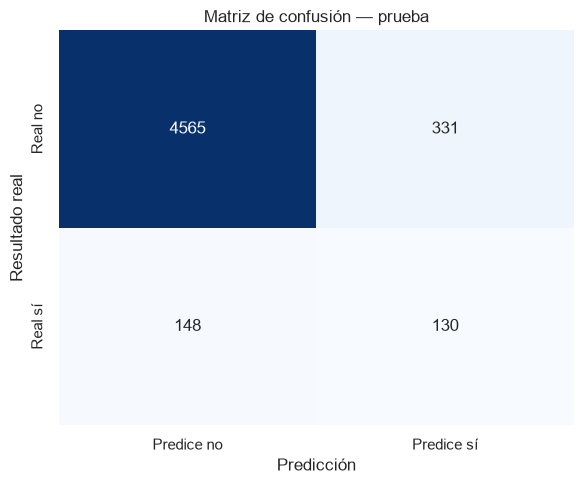

Verdaderos negativos: 4,565
Falsos positivos: 331
Falsos negativos: 148
Verdaderos positivos: 130


In [9]:
matriz = confusion_matrix(y_test, predicciones)
tn, fp, fn, tp = matriz.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["Predice no", "Predice sí"],
    yticklabels=["Real no", "Real sí"],
)
plt.title("Matriz de confusión — prueba")
plt.xlabel("Predicción")
plt.ylabel("Resultado real")
plt.tight_layout()
plt.show()

print(f"Verdaderos negativos: {tn:,}")
print(f"Falsos positivos: {fp:,}")
print(f"Falsos negativos: {fn:,}")
print(f"Verdaderos positivos: {tp:,}")

### Interpretación

La matriz contiene cuatro resultados:

- **4.565 verdaderos negativos:** el modelo dijo “no habrá desviación” y efectivamente no ocurrió. Son decisiones correctas sin alerta.
- **130 verdaderos positivos:** el modelo generó una alerta y sí ocurrió una desviación. Son las alertas útiles.
- **331 falsos positivos:** el modelo generó una alerta, pero no ocurrió una desviación. Representan revisiones innecesarias.
- **148 falsos negativos:** el modelo no generó una alerta, pero sí ocurrió una desviación. Representan eventos que podrían pasar inadvertidos.

Para AndinaLog, el falso negativo puede ser más costoso porque afecta la posibilidad de actuar antes de una desviación. El falso positivo también importa porque consume tiempo de revisión.

El notebook conserva el umbral 0,50. Antes de cambiarlo, la empresa debe definir cuánto cuesta cada tipo de error y evaluar otro umbral usando validación dentro del entrenamiento, no la prueba final.

## 9. Análisis según la desviación térmica actual

La evaluación general puede ocultar diferencias importantes. Por eso se separan las lecturas según el valor disponible en el instante de predicción:

- `desviacion_termica_flag = 0`: todavía no existe una desviación.
- `desviacion_termica_flag = 1`: la desviación ya está presente.

Este análisis no cambia el modelo ni el umbral. Solamente explica en qué situaciones acierta y en cuáles falla.

,lecturas,positivos_reales,VN,FP,FN,VP,recall_pct,precision_pct
grupo,,,,,,,,
Sin desviación actual,4976,158,4565,253,148,10,6.33,3.80
Con desviación actual,198,120,0,78,0,120,100.00,60.61


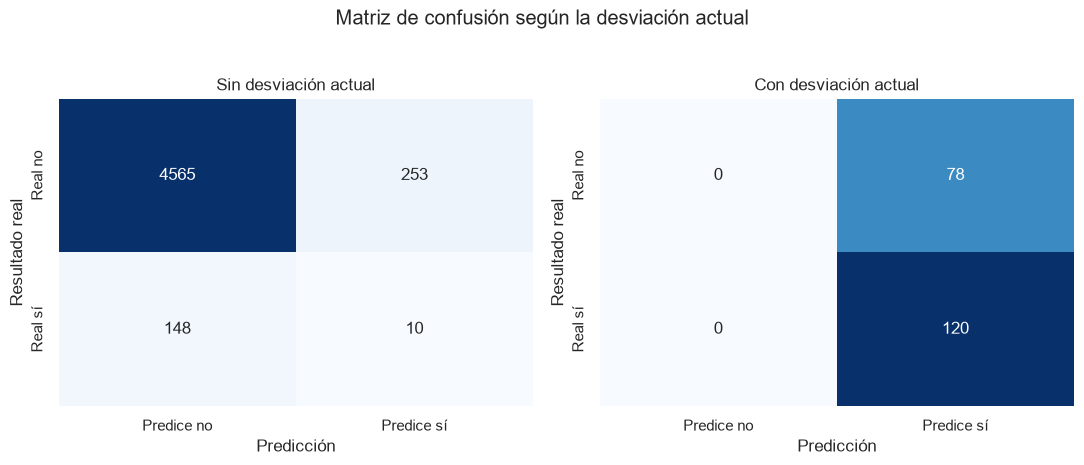

In [10]:
evaluacion_segmentada = X_test.copy()
evaluacion_segmentada["objetivo_real"] = y_test.to_numpy()
evaluacion_segmentada["prediccion"] = predicciones
evaluacion_segmentada["probabilidad"] = probabilidades

filas_segmentos = []
matrices_segmentos = {}

for valor_flag, nombre in [(0, "Sin desviación actual"), (1, "Con desviación actual")]:
    segmento = evaluacion_segmentada.loc[
        evaluacion_segmentada["desviacion_termica_flag"].eq(valor_flag)
    ]
    matriz_segmento = confusion_matrix(
        segmento["objetivo_real"], segmento["prediccion"], labels=[0, 1]
    )
    tn_s, fp_s, fn_s, tp_s = matriz_segmento.ravel()
    matrices_segmentos[nombre] = matriz_segmento
    filas_segmentos.append({
        "grupo": nombre,
        "lecturas": len(segmento),
        "positivos_reales": int(segmento["objetivo_real"].sum()),
        "VN": int(tn_s),
        "FP": int(fp_s),
        "FN": int(fn_s),
        "VP": int(tp_s),
        "recall_pct": recall_score(
            segmento["objetivo_real"], segmento["prediccion"], zero_division=0
        ) * 100,
        "precision_pct": precision_score(
            segmento["objetivo_real"], segmento["prediccion"], zero_division=0
        ) * 100,
    })

metricas_segmentadas = pd.DataFrame(filas_segmentos).set_index("grupo")
display(metricas_segmentadas.round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (nombre, matriz_segmento) in zip(axes, matrices_segmentos.items()):
    sns.heatmap(
        matriz_segmento,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Predice no", "Predice sí"],
        yticklabels=["Real no", "Real sí"],
        ax=ax,
    )
    ax.set_title(nombre)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Resultado real")

plt.suptitle("Matriz de confusión según la desviación actual", y=1.03)
plt.tight_layout()
plt.show()

### Interpretación

Esta separación revela un problema que no era visible en la matriz general.

**Cuando la lectura actual todavía es normal:**

- Hay 4.976 lecturas.
- En 158 ocurre una desviación durante la hora siguiente.
- El modelo detecta solamente 10.
- Deja sin alerta 148.
- El recall es 6,33 %.

Esto significa que, de cada 100 desviaciones que comienzan desde un estado normal, el modelo detecta aproximadamente 6.

**Cuando ya existe una desviación actual:**

- Hay 198 lecturas.
- En 120 continúa o vuelve a aparecer una desviación futura.
- El modelo detecta las 120.
- También genera alertas en los otros 78 casos.

El recall de 100 % en este grupo no significa que el modelo distinga perfectamente. En realidad, responde “sí” para las 198 lecturas. Por eso detecta todos los eventos, pero también todas las situaciones que después no presentan una desviación.

Los 148 falsos negativos pertenecen al grupo inicialmente normal. Además, 120 de los 130 aciertos positivos ya tenían una desviación. La evidencia indica que el modelo reconoce principalmente la **continuidad de un problema existente**, no la aparición temprana de un evento nuevo.

## 10. Probabilidades según el estado actual

El siguiente gráfico permite comprobar si el modelo asigna probabilidades diferentes a los casos que realmente tendrán o no una desviación futura.

count   mean  median
Estado actual         Resultado futuro                      
Con desviación actual No ocurre            78  95.46   96.45
                      Sí ocurre           120  96.62   96.99
Sin desviación actual No ocurre          4818  34.35   29.68
                      Sí ocurre           158  37.14   40.72

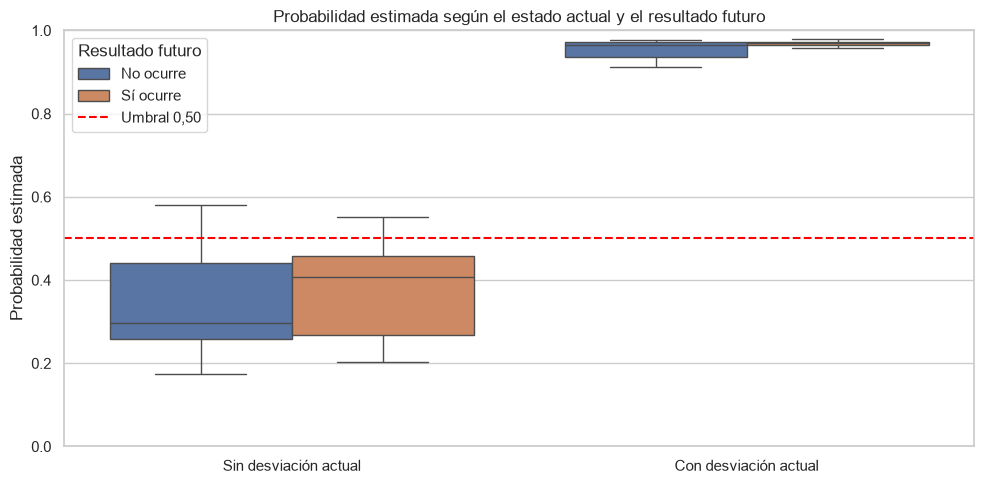

In [11]:
grafico_probabilidades = evaluacion_segmentada.copy()
grafico_probabilidades["Estado actual"] = grafico_probabilidades[
    "desviacion_termica_flag"
].map({0: "Sin desviación actual", 1: "Con desviación actual"})
grafico_probabilidades["Resultado futuro"] = grafico_probabilidades[
    "objetivo_real"
].map({0: "No ocurre", 1: "Sí ocurre"})

resumen_probabilidades = (
    grafico_probabilidades
    .groupby(["Estado actual", "Resultado futuro"])["probabilidad"]
    .agg(["count", "mean", "median"])
)
display((resumen_probabilidades * pd.Series({"count": 1, "mean": 100, "median": 100})).round(2))

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=grafico_probabilidades,
    x="Estado actual",
    y="probabilidad",
    hue="Resultado futuro",
    showfliers=False,
)
plt.axhline(CONFIG["umbral"], color="red", linestyle="--", label="Umbral 0,50")
plt.ylim(0, 1)
plt.title("Probabilidad estimada según el estado actual y el resultado futuro")
plt.xlabel("")
plt.ylabel("Probabilidad estimada")
plt.legend(title="Resultado futuro")
plt.tight_layout()
plt.show()

### Interpretación

La línea roja del gráfico representa el umbral 0,50. Los puntos o cajas que quedan por encima generan una alerta.

Cuando no existe una desviación actual:

- Los casos que permanecen normales reciben una probabilidad media de 34,35 %.
- Los casos que después presentan una desviación reciben 37,14 %.

La diferencia es de menos de tres puntos porcentuales. Como ambos grupos se mezclan ampliamente, el modelo tiene dificultades para reconocer cuál lectura normal está a punto de convertirse en una desviación.

Cuando ya existe una desviación actual, ambos grupos reciben probabilidades superiores al 90 %. El modelo interpreta la presencia del problema actual como una señal muy fuerte y coloca todos los casos por encima del umbral, incluso aquellos que después vuelven a la normalidad.

Por tanto, el gráfico confirma que el problema no se resuelve simplemente leyendo la probabilidad: falta información que permita separar mejor los nuevos eventos.

## 11. Comparación diagnóstica sin la desviación actual

Como comprobación adicional se entrena el mismo tipo de modelo sin `desviacion_termica_flag`. Esta comparación es solo diagnóstica: no reemplaza el modelo oficial, porque la tarea exige las cinco predictoras mínimas.

In [12]:
predictores_sin_flag = [
    predictor for predictor in CONFIG["predictores"]
    if predictor != "desviacion_termica_flag"
]

modelo_sin_flag = Pipeline(steps=[
    ("imputacion", SimpleImputer(strategy="median")),
    ("escalado", StandardScaler()),
    ("regresion", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=CONFIG["semilla"],
    )),
])

modelo_sin_flag.fit(X_train[predictores_sin_flag], y_train)
probabilidades_sin_flag = modelo_sin_flag.predict_proba(
    X_test[predictores_sin_flag]
)[:, 1]
predicciones_sin_flag = (
    probabilidades_sin_flag >= CONFIG["umbral"]
).astype(int)

comparacion_diagnostica = pd.DataFrame([
    calcular_metricas(
        "Modelo oficial con flag", y_test, predicciones, probabilidades
    ),
    calcular_metricas(
        "Diagnóstico sin flag", y_test, predicciones_sin_flag,
        probabilidades_sin_flag,
    ),
]).set_index("modelo")

display(comparacion_diagnostica.round(4))

,precision,recall,f1,roc_auc,pr_auc
modelo,,,,,
Modelo oficial con flag,0.2820,0.4676,0.3518,0.7489,0.3732
Diagnóstico sin flag,0.0845,0.6295,0.1491,0.6603,0.1641


### Interpretación

Esta comparación pregunta qué ocurriría si el modelo no conociera `desviacion_termica_flag`.

- Con el flag, el recall es 46,76 %, la precisión 28,20 % y el PR AUC 37,32 %.
- Sin el flag, el recall sube a 62,95 %, pero la precisión cae a 8,45 % y el PR AUC baja a 16,41 %.

El recall aumenta porque el modelo sin el flag genera muchas más alertas: pasa de 461 a 2.070 predicciones positivas. Por eso encuentra más eventos, pero también envía muchas revisiones innecesarias.

La conclusión no es que debamos eliminar el flag. La variable aporta información real y además es obligatoria en la tarea. El diagnóstico muestra que las otras cuatro variables no son suficientes para anticipar con claridad las desviaciones nuevas. Una mejora futura necesitaría evaluar específicamente los casos inicialmente normales e incorporar información operativa adicional.

## 12. Curvas ROC y precisión-recall

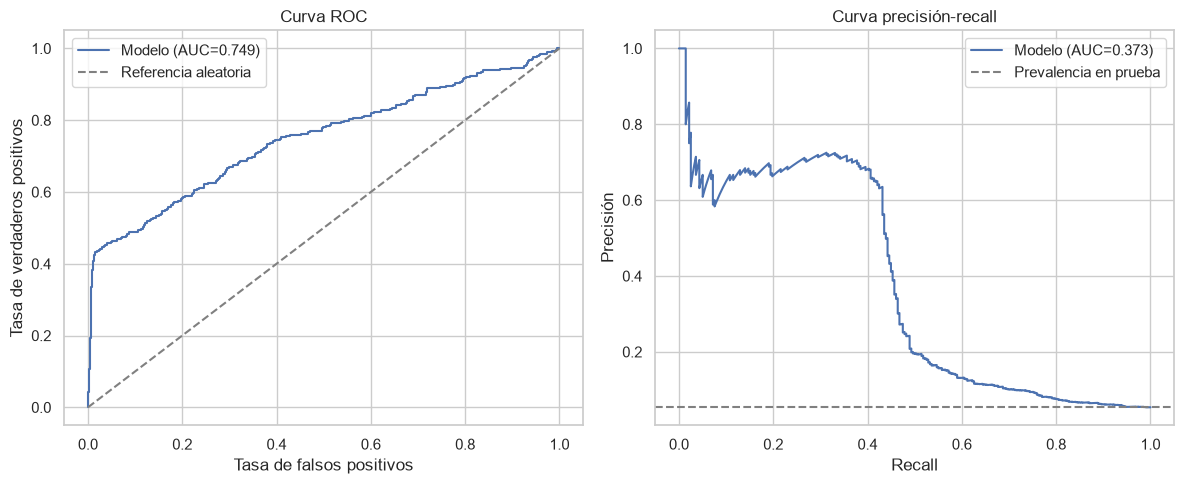

In [13]:
fpr, tpr, _ = roc_curve(y_test, probabilidades)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, probabilidades)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, label=f"Modelo (AUC={metricas.loc['Regresión logística', 'roc_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="Referencia aleatoria")
axes[0].set_title("Curva ROC")
axes[0].set_xlabel("Tasa de falsos positivos")
axes[0].set_ylabel("Tasa de verdaderos positivos")
axes[0].legend()

axes[1].plot(recall_curve, precision_curve, label=f"Modelo (AUC={metricas.loc['Regresión logística', 'pr_auc']:.3f})")
axes[1].axhline(y_test.mean(), linestyle="--", color="gray", label="Prevalencia en prueba")
axes[1].set_title("Curva precisión-recall")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precisión")
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpretación

Las curvas muestran qué sucede si se baja o se sube el umbral de alerta:

- Un umbral más bajo suele detectar más desviaciones, pero también genera más falsas alertas.
- Un umbral más alto reduce alertas innecesarias, pero puede dejar pasar más eventos reales.

El ROC AUC de 74,89 % indica una capacidad general moderada para ordenar el riesgo. El PR AUC de 37,32 % es mejor que la referencia de 5,37 %, aunque está lejos de una separación perfecta.

Estas curvas sirven para comprender el comportamiento del modelo. No se utilizan aquí para seleccionar un nuevo umbral, porque hacerlo con la prueba final produciría una evaluación demasiado optimista.

## 13. Coeficientes del modelo

,predictor,coeficiente_escalado,efecto_en_la_probabilidad
2,desviacion_termica_flag,0.686,aumenta la probabilidad estimada
1,humedad_cabina_pct,0.296,aumenta la probabilidad estimada
0,temperatura_cabina_c,0.176,aumenta la probabilidad estimada
4,variacion_temperatura_30min,-0.018,disminuye la probabilidad estimada
3,temperatura_anterior,-0.364,disminuye la probabilidad estimada


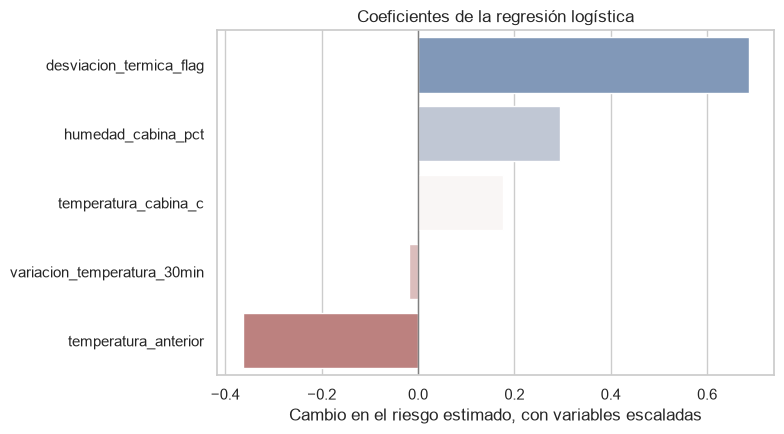

In [14]:
coeficientes = pd.DataFrame({
    "predictor": CONFIG["predictores"],
    "coeficiente_escalado": modelo.named_steps["regresion"].coef_[0],
})
coeficientes["efecto_en_la_probabilidad"] = np.where(
    coeficientes["coeficiente_escalado"] > 0,
    "aumenta la probabilidad estimada",
    "disminuye la probabilidad estimada",
)
coeficientes = coeficientes.sort_values("coeficiente_escalado", ascending=False)
display(coeficientes.round({"coeficiente_escalado": 3}))

plt.figure(figsize=(8, 4.5))
sns.barplot(data=coeficientes, x="coeficiente_escalado", y="predictor", hue="predictor", legend=False, palette="vlag")
plt.axvline(0, color="gray", linewidth=1)
plt.title("Coeficientes de la regresión logística")
plt.xlabel("Cambio en el riesgo estimado, con variables escaladas")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Interpretación

Los coeficientes indican hacia qué dirección mueve cada variable la probabilidad estimada cuando las demás permanecen constantes:

- Un valor positivo aumenta la probabilidad calculada.
- Un valor negativo la disminuye.
- Un valor cercano a cero aporta poco a la separación lineal realizada por este modelo.

`desviacion_termica_flag` tiene el coeficiente positivo más alto. Esto coincide con el análisis anterior: saber que la desviación ya existe modifica fuertemente la predicción.

La humedad y la temperatura actual también aportan información. La variación de 30 minutos tiene un coeficiente cercano a cero en este ajuste, lo que indica que su contribución lineal adicional es pequeña después de considerar las otras variables.

Como las variables fueron escaladas, las magnitudes son comparables dentro de este modelo. Sin embargo, un coeficiente no demuestra causalidad. No podemos concluir, por ejemplo, que aumentar la humedad cause por sí solo una desviación futura.

## 14. Limitaciones y reproducibilidad

### Limitaciones

- La desviación futura es poco frecuente. Esto hace que la exactitud general pueda parecer buena aunque se pierdan casos importantes.
- Cuando el estado actual todavía es normal, el modelo separa débilmente las lecturas que después tendrán una desviación.
- El resultado corresponde a una sola división por viaje con semilla fija. Debe confirmarse con viajes nuevos antes de cualquier uso operativo.
- El umbral 0,50 no fue optimizado con el conjunto de prueba. Cambiarlo alteraría el equilibrio entre desviaciones detectadas y falsas alertas.
- La comparación sin `desviacion_termica_flag` es únicamente diagnóstica y no reemplaza el modelo oficial.
- Los coeficientes describen asociaciones aprendidas por el modelo; no demuestran causas físicas u operativas.
- El modelo no debe tomar decisiones automáticas sin supervisión y validación adicional.

### Reproducibilidad

El notebook registra la semilla, versiones de las bibliotecas, número de filas, viajes de entrenamiento y prueba, umbral y ruta del archivo utilizado. Al ejecutarlo nuevamente con los mismos datos y versiones, debe producir resultados equivalentes.

### Informe Markdown

La siguiente celda genera el informe Markdown como material adicional de estudio. Todas sus explicaciones importantes también están incluidas en las secciones anteriores de este notebook.

In [15]:
informe = f'''# Informe 05 — Regresión logística IoT

## Metodología

- Filas modeladas: {len(modelado):,}
- Entrenamiento: {len(X_train):,} filas y {grupos_train.nunique():,} viajes
- Prueba: {len(X_test):,} filas y {grupos_test.nunique():,} viajes
- Viajes compartidos: {len(viajes_compartidos)}
- Semilla: {CONFIG['semilla']}
- Umbral: {CONFIG['umbral']:.2f}
- Clase positiva en prueba: {y_test.mean() * 100:.2f}%
- Modelo: regresión logística con `class_weight="balanced"`
- Preparación: imputación por mediana y escalado ajustados solo con entrenamiento

## Resultados finales en prueba

- Precisión: {metricas.loc['Regresión logística', 'precision']:.4f}
- Recall: {metricas.loc['Regresión logística', 'recall']:.4f}
- F1: {metricas.loc['Regresión logística', 'f1']:.4f}
- ROC AUC: {metricas.loc['Regresión logística', 'roc_auc']:.4f}
- PR AUC: {metricas.loc['Regresión logística', 'pr_auc']:.4f}
- Verdaderos negativos: {tn:,}
- Falsos positivos: {fp:,}
- Falsos negativos: {fn:,}
- Verdaderos positivos: {tp:,}

## Resultado según la desviación actual

### Sin desviación actual

- Lecturas: {int(metricas_segmentadas.loc['Sin desviación actual', 'lecturas']):,}
- Desviaciones futuras reales: {int(metricas_segmentadas.loc['Sin desviación actual', 'positivos_reales']):,}
- Verdaderos positivos: {int(metricas_segmentadas.loc['Sin desviación actual', 'VP']):,}
- Falsos negativos: {int(metricas_segmentadas.loc['Sin desviación actual', 'FN']):,}
- Falsos positivos: {int(metricas_segmentadas.loc['Sin desviación actual', 'FP']):,}
- Recall: {metricas_segmentadas.loc['Sin desviación actual', 'recall_pct']:.2f}%
- Precisión: {metricas_segmentadas.loc['Sin desviación actual', 'precision_pct']:.2f}%

### Con desviación actual

- Lecturas: {int(metricas_segmentadas.loc['Con desviación actual', 'lecturas']):,}
- Desviaciones futuras reales: {int(metricas_segmentadas.loc['Con desviación actual', 'positivos_reales']):,}
- Verdaderos positivos: {int(metricas_segmentadas.loc['Con desviación actual', 'VP']):,}
- Falsos negativos: {int(metricas_segmentadas.loc['Con desviación actual', 'FN']):,}
- Falsos positivos: {int(metricas_segmentadas.loc['Con desviación actual', 'FP']):,}
- Recall: {metricas_segmentadas.loc['Con desviación actual', 'recall_pct']:.2f}%
- Precisión: {metricas_segmentadas.loc['Con desviación actual', 'precision_pct']:.2f}%

## Interpretación

El modelo depende fuertemente de la desviación actual. Cuando la lectura todavía es normal, detecta solamente 10 de 158 desviaciones futuras. Cuando la desviación ya está presente, genera una alerta para todos los casos del grupo: detecta las 120 continuaciones, pero también produce 78 falsas alertas.

Por tanto, el desempeño global describe principalmente la continuidad de desviaciones existentes y no representa adecuadamente la capacidad de anticipar eventos nuevos.

## Comparación diagnóstica

El modelo sin `desviacion_termica_flag` aumenta el recall, pero reduce fuertemente la precisión y el PR AUC. Esta comparación no reemplaza el modelo oficial y no se utilizó para ajustar el umbral con la prueba.

## Línea base

La referencia siempre predice la clase 0. Su recall y F1 son 0 porque no identifica ninguna desviación futura.

## Limitaciones

- La clase positiva es poco frecuente.
- El modelo separa débilmente las nuevas desviaciones cuando el estado actual es normal.
- La evaluación corresponde a una sola división por viaje con semilla fija.
- No se optimizó el umbral con la prueba.
- Los coeficientes muestran asociaciones y no efectos causales.

## Reproducibilidad

- Python: {platform.python_version()}
- pandas: {pd.__version__}
- NumPy: {np.__version__}
- scikit-learn: {sklearn.__version__}
- Ejecución UTC: {datetime.now(timezone.utc).isoformat()}
'''

RUTA_INFORME.write_text(informe, encoding="utf-8")
print("Informe generado:", RUTA_INFORME.resolve())

Informe generado: C:\Users\remrodri\Documents\Codex\2026-09-28\referenced-chatgpt-conversation-this-is-an\outputs\05_regresion_logistica_iot\Informe_05_Regresion_Logistica_IoT.md


## 15. Conclusión

El modelo general supera la línea base y proporciona una señal útil para ordenar las revisiones. En la prueba detecta 130 de las 278 desviaciones reales, pero también deja sin alerta 148 y genera 331 alertas innecesarias.

El análisis detallado muestra que la mayoría de sus aciertos positivos ocurre cuando el problema ya estaba presente:

- Con desviación actual, genera una alerta para todos los casos.
- Sin desviación actual, detecta solamente 10 de 158 eventos nuevos.

Por eso, el resultado es más útil para reconocer que una desviación existente puede continuar que para funcionar como una alerta temprana de nuevas desviaciones.

El modelo no debe utilizarse para decisiones automáticas. Antes de un uso operativo, AndinaLog debería:

1. Validarlo con viajes nuevos.
2. Definir el costo de omitir una desviación y el costo de revisar una falsa alerta.
3. Evaluar por separado los eventos que comienzan desde una lectura normal.
4. Incorporar variables operativas adicionales si están disponibles.

Estas conclusiones describen asociaciones encontradas en los datos. No prueban las causas físicas u operativas de las desviaciones.